# Maintenance Prédictive des Éoliennes
## Classification multiclasse — Turbine 1

Ce notebook couvre l'analyse exploratoire, le nettoyage des données, la construction d'un pipeline de preprocessing et la comparaison de plusieurs modèles de classification pour prédire les besoins de maintenance (labels 0, 1, 2).

**Métrique cible :** F1-Score macro — toutes les classes comptent également, y compris les pannes rares.

---
### Import des librairies

In [1]:
import warnings
# Suppression du DeprecationWarning interne scipy/sklearn (lbfgs disp/iprint)
warnings.filterwarnings('ignore', message='.*disp.*', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*iprint.*', category=DeprecationWarning)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
from dotenv import load_dotenv
import boto3

---
## Import du dataset

Les données proviennent d'un bucket S3 (accès via variables d'environnement). En développement local, on peut également charger les fichiers directement depuis `data/raw/`.

CHARGEMENT DES CREDENTIALS AWS

In [30]:
try:
    load_dotenv()
    acces_key = os.getenv("AWS_ACCESS_KEY_ID")
    s_acces_key = os.getenv("AWS_SECRET_ACCESS_KEY")
    print("Credentials AWS chargés.")
except Exception as e:
    print(f"[INFO] Credentials AWS non disponibles : {e}")

CONSULTATION DES FICHIERS S3

In [31]:
try:
    import boto3
    s3 = boto3.client('s3')
    for obj in s3.list_objects_v2(Bucket='projet-certif-dsfs-ft-38')['Contents']:
        print(f"  {obj['Key']}")
except Exception as e:
    print(f"[INFO] Accès S3 non disponible : {e}")

AccessDenied: An error occurred (AccessDenied) when calling the ListObjectsV2 operation: Access Denied

IMPORT S3

In [ ]:
try:
    load_dotenv()
    acces_key = os.getenv("AWS_ACCESS_KEY_ID")
    s_acces_key = os.getenv("AWS_SECRET_ACCESS_KEY")
    session = boto3.Session(aws_access_key_id=acces_key, aws_secret_access_key=s_acces_key)
    s3 = session.resource("s3")
    bucket = s3.Bucket("projet-certif-dsfs-ft-38")
    obj = bucket.Object("dataset/Wind Turbine Predictive Maintenance_KAGGLE/wind_turbine_maintenance_data.csv")
    dataset = pd.read_csv(obj.get()['Body'])
    print("Dataset importé depuis S3.")
except Exception as e:
    print(f"[INFO] Import S3 non disponible : {e}")
    print("Utilisation du chargement local (cellule suivante).")

AccessDenied: An error occurred (AccessDenied) when calling the GetObject operation: Access Denied

**Chargement local** — import depuis le dossier `data/raw/` (mode développement)

In [2]:
dataset = pd.read_csv('../data/raw/wind_turbine_maintenance_data.csv')

---
## 1. Analyse Exploratoire des Données (EDA)

On commence par examiner la structure du dataset : dimensions, types de variables, valeurs manquantes et distributions. Cela guide les choix de nettoyage et de preprocessing.

In [3]:
# Dimensions et aperçu du dataset
print("Nombre de lignes : {}".format(dataset.shape[0]))
print()

print("Aperçu du dataset :")
display(dataset.head())
print()

print("Statistiques descriptives :")
data_desc = dataset.describe(include='all')
display(data_desc)
print()

print("Pourcentage de valeurs manquantes :")
display(100 * dataset.isnull().sum() / dataset.shape[0])

Nombre de lignes : 35040

Aperçu du dataset :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
0,1,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0
1,1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0
2,1,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0
3,1,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0
4,1,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1



Statistiques descriptives :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,1.500000,14.998813,7.991100,1500.087340,65.007705,75.014411,2.001254,10.011707,59.945455,0.247317
std,0.500007,0.996711,1.000523,100.308440,4.987860,4.985797,0.198647,5.033105,9.991139,0.591441
min,1.000000,11.139053,3.801420,1096.556628,44.676878,52.685157,1.194998,-12.021070,15.434405,0.000000
25%,1.000000,14.324117,7.322801,1431.894808,61.662044,71.634222,1.867094,6.618438,53.198579,0.000000
50%,1.500000,14.995670,7.992324,1500.080064,64.991915,75.034723,2.000812,9.981060,59.945151,0.000000
75%,2.000000,15.670454,8.658140,1568.095394,68.353356,78.401443,2.136039,13.411453,66.668883,0.000000
max,2.000000,19.616726,11.824992,1914.789505,86.096832,96.494288,2.842975,34.007573,105.255483,2.000000



Pourcentage de valeurs manquantes :


Turbine_ID                  0.0
Rotor_Speed_RPM             0.0
Wind_Speed_mps              0.0
Power_Output_kW             0.0
Gearbox_Oil_Temp_C          0.0
Generator_Bearing_Temp_C    0.0
Vibration_Level_mmps        0.0
Ambient_Temp_C              0.0
Humidity_pct                0.0
Maintenance_Label           0.0
dtype: float64

### Distribution des classes et des turbines

On vérifie la répartition entre les deux turbines et la distribution des labels de maintenance. Un fort déséquilibre de classes justifiera l'usage de `class_weight='balanced'` dans les modèles.

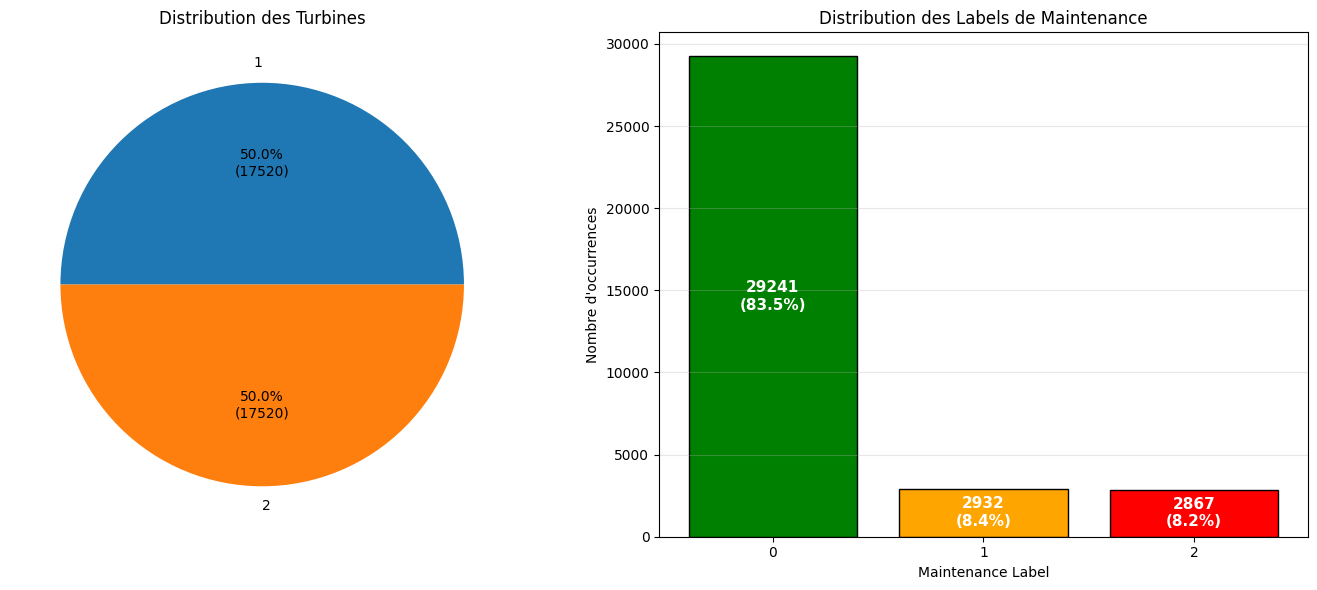

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PIE CHART - Turbine IDs
turbine_counts = dataset['Turbine_ID'].value_counts().sort_index()
axes[0].pie(turbine_counts.values, 
            labels=turbine_counts.index, 
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*turbine_counts.sum())})')
axes[0].set_title("Distribution des Turbines")

# BAR CHART - Maintenance Labels
maintenance_counts = dataset['Maintenance_Label'].value_counts()
total = maintenance_counts.sum()
colors = {0: 'green', 1: 'orange', 2: 'red'}
bar_colors = [colors[label] for label in maintenance_counts.index]

container = axes[1].bar(maintenance_counts.index, maintenance_counts.values, color=bar_colors, edgecolor='black')

# Ajouter count + pourcentage DANS les barres
for label, count in zip(maintenance_counts.index, maintenance_counts.values):
    percentage = count / total * 100
    axes[1].text(label, count/2, f'{count}\n({percentage:.1f}%)', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

axes[1].set_title("Distribution des Labels de Maintenance")
axes[1].set_xlabel("Maintenance Label")
axes[1].set_ylabel("Nombre d'occurrences")
axes[1].set_xticks([0, 1, 2]) 
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

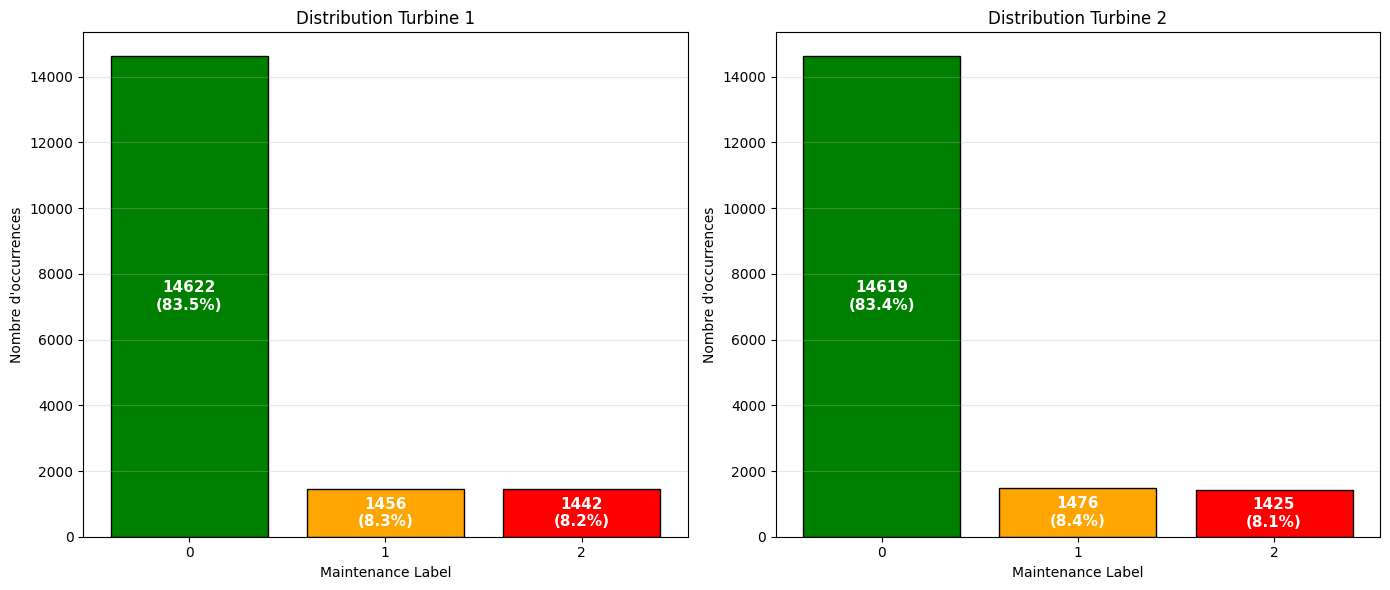

In [5]:
def plot_turbine(ax, turbine_id):
    counts = dataset[dataset['Turbine_ID'] == turbine_id]['Maintenance_Label'].value_counts().sort_index()
    total = counts.sum()
    
    colors = {0: 'green', 1: 'orange', 2: 'red'}
    bar_colors = [colors[label] for label in counts.index]
    
    container = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='black')
    
    # Ajouter count + pourcentage DANS les barres
    for i, (label, count) in enumerate(zip(counts.index, counts.values)):
        percentage = count / total * 100
        ax.text(label, count/2, f'{count}\n({percentage:.1f}%)', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    
    ax.set_title(f"Distribution Turbine {turbine_id}")
    ax.set_xlabel("Maintenance Label")
    ax.set_ylabel("Nombre d'occurrences")
    ax.set_xticks([0, 1, 2])
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_turbine(axes[0], 1)
plot_turbine(axes[1], 2)

plt.tight_layout()
plt.show()

### Séparation par turbine

Le dataset contient deux turbines (ID 1 et 2). On les sépare pour travailler indépendamment sur chacune. La suite du notebook se concentre sur la **Turbine 1**.

In [6]:
Turbine1 = dataset[dataset['Turbine_ID'] == 1]
Turbine2 = dataset[dataset['Turbine_ID'] == 2]

### Matrice de corrélation

On visualise les corrélations entre variables numériques pour chaque turbine. Des corrélations fortes entre features peuvent indiquer de la redondance d'information.

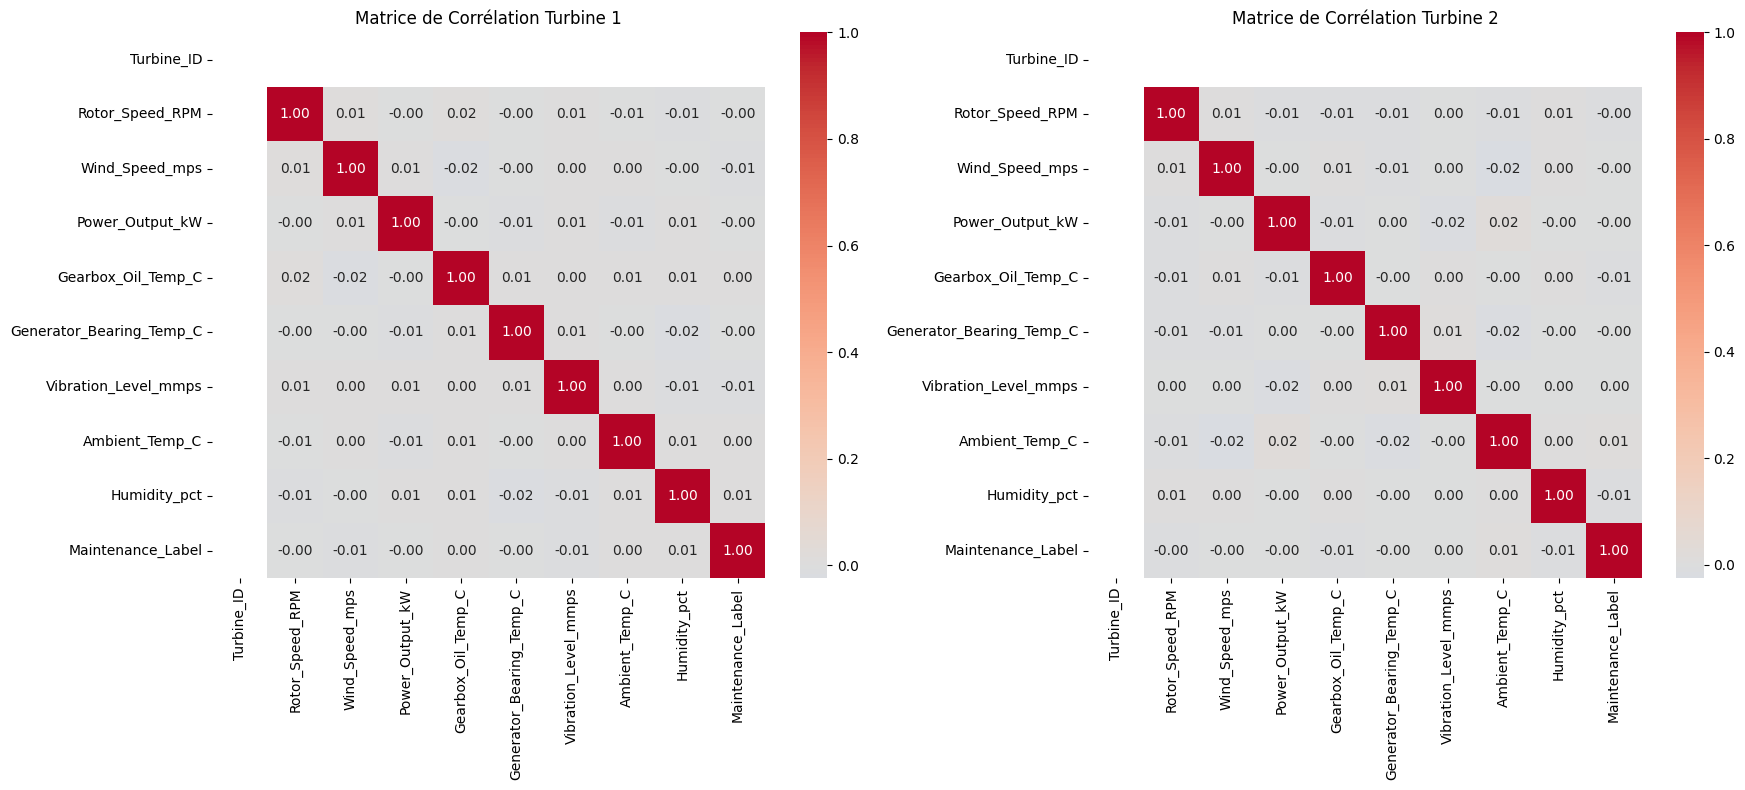

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Turbine 1
turbine1 = dataset[dataset['Turbine_ID'] == 1]
correlation_matrix1 = turbine1.corr()
sns.heatmap(correlation_matrix1, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[0])
axes[0].set_title('Matrice de Corrélation Turbine 1')

# Turbine 2
turbine2 = dataset[dataset['Turbine_ID'] == 2]
correlation_matrix2 = turbine2.corr()
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Matrice de Corrélation Turbine 2')

plt.tight_layout()
plt.show()

In [8]:
# Aperçu du sous-dataset Turbine 1 avant nettoyage
Turbine1.head(10)

,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
0,1,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0
1,1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0
2,1,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0
3,1,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0
4,1,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1
5,1,14.156580,7.486675,1495.646320,63.623495,67.184666,1.840874,14.652922,66.777674,0
6,1,15.211587,8.597045,1410.366482,64.440061,82.344706,1.775220,14.750027,77.265165,0
7,1,14.927990,9.003533,1536.163603,61.774401,76.806978,2.307607,9.820870,75.646437,0
8,1,14.601362,7.939136,1358.124954,70.212458,79.517662,2.003800,7.327918,45.049461,0
9,1,16.622920,8.823733,1529.305925,69.483152,71.948390,1.936767,2.587879,57.711525,0


---
## 2. Nettoyage du dataset

On supprime les colonnes inutiles ou avec trop de valeurs manquantes. L'identifiant de turbine n'est plus nécessaire puisqu'on travaille sur Turbine 1 uniquement.

In [9]:
# Suppression des colonnes inutiles / trop de valeurs manquantes
useless_cols = ['Turbine_ID', 'Ambient_Temp_C', 'Humidity_pct']

print("Suppression des colonnes non pertinentes...")
Turbine1 = Turbine1.drop(useless_cols, axis=1)
print("Fait.")
print(Turbine1.head())

# Sauvegarde du dataset nettoyé dans le dossier processed
Turbine1.to_csv('../data/processed/dataset.csv', index=False)
print("\nDataset nettoyé sauvegardé dans data/processed/dataset.csv")

Suppression des colonnes non pertinentes...
Fait.
   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  Maintenance_Label  
0                 73.829233              1.953173                  0  
1                 72.340913              1.976505                  0  
2                 71.998731              2.189488                  0  
3                 68.359070              2.039372                  0  
4                 86.703732              2.214197                  1  

Dataset nettoyé sauvegardé dans data/processed/dataset.csv


---
## 3. Préparation des données

### Séparation features / cible

On isole la variable cible `Maintenance_Label` du reste des features.

In [13]:
# Séparation de la variable cible et des features
target_name = 'Maintenance_Label'

print("Séparation cible / features...")
Y = Turbine1[target_name]
X = Turbine1.drop(target_name, axis=1)
print("Fait.")
print(Y.head())
print()
print(X.head())
print()


Séparation cible / features...
Fait.
0    0
1    0
2    0
3    0
4    1
Name: Maintenance_Label, dtype: int64

   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  
0                 73.829233              1.953173  
1                 72.340913              1.976505  
2                 71.998731              2.189488  
3                 68.359070              2.039372  
4                 86.703732              2.214197  



In [14]:
print("Découpage train / test (split chronologique)...")

# shuffle=False : on respecte l'ordre temporel des observations
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print("Fait.")
print()
print(f"Train set : {X_train.shape}")
print(f"Test set  : {X_test.shape}")

print(f"\nDistribution des classes dans le train set :")
print(Y_train.value_counts(normalize=True))

Découpage train / test (split chronologique)...
Fait.

Train set : (14016, 6)
Test set  : (3504, 6)

Distribution des classes dans le train set :
Maintenance_Label
0    0.834332
2    0.084332
1    0.081336
Name: proportion, dtype: float64


In [15]:
# Vérification des features après séparation
X.head()

,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps
0,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173
1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505
2,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488
3,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372
4,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197


### Preprocessing

On construit un pipeline de transformation : imputation des valeurs manquantes + standardisation pour les variables numériques, et encodage One-Hot pour les variables catégorielles (s'il y en a).

In [16]:
# Détection automatique des colonnes numériques et catégorielles
numeric_features = []
categorical_features = []

for col, dtype in X_train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        if col != 'Maintenance_Label':
            categorical_features.append(col)

print("Features numériques :", numeric_features)
print("Features catégorielles :", categorical_features)
print()

# Pipeline pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

print("Pipeline numérique créé.")
print()

# Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ])

print("Pipeline catégoriel créé.")
print()

# Assemblage du preprocesseur global via ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocesseur assemblé avec succès !")
print()


Features numériques : ['Rotor_Speed_RPM', 'Wind_Speed_mps', 'Power_Output_kW', 'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C', 'Vibration_Level_mmps']
Features catégorielles : []

Pipeline numérique créé.

Pipeline catégoriel créé.

Preprocesseur assemblé avec succès !



In [17]:
# Application du preprocessing sur le train set (fit + transform)
print("Preprocessing du train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('Fait.')
print(X_train[0:5, :])
print()

# Application sur le test set (transform uniquement, pas de re-fit !)
print("Preprocessing du test set...")
print(X_test.head())
X_test = preprocessor.transform(X_test)
print('Fait.')
print(X_test[0:5, :])
print()


Preprocessing du train set...
   Rotor_Speed_RPM  Wind_Speed_mps  Power_Output_kW  Gearbox_Oil_Temp_C  \
0        15.496714        7.861736      1564.768854           72.615149   
1        15.079832        7.840483      1502.222183           62.861035   
2        17.559488        8.394233      1512.221917           62.422822   
3        15.822545        6.779156      1520.886360           55.201649   
4        15.564464        8.025501      1547.319325           68.295953   

   Generator_Bearing_Temp_C  Vibration_Level_mmps  
0                 73.829233              1.953173  
1                 72.340913              1.976505  
2                 71.998731              2.189488  
3                 68.359070              2.039372  
4                 86.703732              2.214197  
Fait.
[[ 0.50241113 -0.14407207  0.64807446  1.5173422  -0.23704066 -0.23501827]
 [ 0.08286891 -0.16556134  0.02869452 -0.43283678 -0.53274673 -0.11765959]
 [ 2.57834635  0.39436531  0.12771873 -0.5204506  -

---
## 4. Modélisation

### Baseline — DummyClassifier

Avant tout modèle réel, on définit une baseline naïve : le `DummyClassifier` prédit toujours la classe majoritaire. C'est le plancher à dépasser absolument.

In [18]:
# DummyClassifier
print("\n" + "="*80)
print("DUMMYCLASSIFIER - STRATÉGIE 'most_frequent'")
print("-" * 80)

print("""
Stratégie 'most_frequent':
- Prédit toujours la classe majoritaire (Y=0 - Pas de maintenance)
- Ne fait aucun apprentissage des features
- Sert de baseline minimale à battre
""")

# Créer le DummyClassifier
dummy_clf = DummyClassifier(
    strategy='most_frequent',
    random_state=42
)

# Entrainement
dummy_clf.fit(X_train, Y_train)

print(f"✓ Modèle 'entraîné'")
most_frequent_class = Y_train.value_counts().idxmax()
print(f"✓ Classe qui sera toujours prédite: {most_frequent_class}")

#--------------------------------------------------------------------------------
# Prédictions
print("\n" + "="*80)
print("PRÉDICTIONS SUR LE TEST SET")
print("-" * 80)

# Faire des prédictions
# Prédictions
Y_train_pred = dummy_clf.predict(X_train)
Y_test_pred = dummy_clf.predict(X_test)

f1_train = f1_score(Y_train, Y_train_pred, average='macro')
f1_test = f1_score(Y_test, Y_test_pred, average='macro')

print(f"F1-Score (macro) Train: {f1_train:.4f}")
print(f"F1-Score (macro) Test: {f1_test:.4f}")


DUMMYCLASSIFIER - STRATÉGIE 'most_frequent'
--------------------------------------------------------------------------------

Stratégie 'most_frequent':
- Prédit toujours la classe majoritaire (Y=0 - Pas de maintenance)
- Ne fait aucun apprentissage des features
- Sert de baseline minimale à battre

✓ Modèle 'entraîné'
✓ Classe qui sera toujours prédite: 0

PRÉDICTIONS SUR LE TEST SET
--------------------------------------------------------------------------------
F1-Score (macro) Train: 0.3032
F1-Score (macro) Test: 0.3035


### Sélection du modèle — tournoi de 3 approches

On compare trois approches par ordre croissant de complexité :
1. **Régression Logistique** (modèle linéaire simple)
2. **Régression Logistique L1 / Lasso** (sélection automatique de features)
3. **Random Forest** (modèle ensembliste non-linéaire)

Le F1-Score macro sur le test set détermine le meilleur candidat.

In [19]:
print("Régression Logistique (modèle linéaire, référence)...")
rl = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000
)
rl.fit(X_train, Y_train)

Y_train_pred = rl.predict(X_train)
Y_test_pred = rl.predict(X_test)

f1_train = f1_score(Y_train, Y_train_pred, average='macro')
f1_test  = f1_score(Y_test,  Y_test_pred,  average='macro')

print(f"F1-Score macro Train : {f1_train:.4f}")
print(f"F1-Score macro Test  : {f1_test:.4f}")

Régression Logistique (modèle linéaire, référence)...


ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

In [47]:
print("\nRégression Logistique L1 / Lasso (sélection de variables)...")
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.01,
    class_weight='balanced',
    max_iter=1000,
    random_state=0
)
lasso.fit(X_train, Y_train)
print("Entraînement terminé.")

Y_train_pred = lasso.predict(X_train)
Y_test_pred  = lasso.predict(X_test)

print("\n" + "="*60)
print("RÉSULTATS LASSO")
print("="*60)

f1_train = f1_score(Y_train, Y_train_pred, average='macro')
f1_test  = f1_score(Y_test,  Y_test_pred,  average='macro')
print(f"F1-Score macro Train : {f1_train:.4f}")
print(f"F1-Score macro Test  : {f1_test:.4f}")

# Pouvoir du Lasso : variables éliminées (coefficient nul)
coeffs = np.sum(np.abs(lasso.coef_), axis=0)
elim = [col for col, c in zip(X.columns, coeffs) if c == 0]
if elim:
    print(f"\nVariables éliminées par le Lasso : {elim}")
else:
    print("\nAucune variable complètement éliminée.")



Training LASSO (Logistic Regression L1)...


/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

In [48]:
print("\nRandom Forest (modèle ensembliste non-linéaire)...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='log2',
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train, Y_train)
print("Entraînement terminé.")

Y_train_pred = rf.predict(X_train)
Y_test_pred  = rf.predict(X_test)

print("\n" + "="*60)
print("RÉSULTATS RANDOM FOREST")
print("="*60)

f1_train = f1_score(Y_train, Y_train_pred, average='macro')
f1_test  = f1_score(Y_test,  Y_test_pred,  average='macro')
print(f"F1-Score macro Train : {f1_train:.4f}")
print(f"F1-Score macro Test  : {f1_test:.4f}")



Training RF (Random Forest)...
...Done.

rf RESULTS
F1-Score (macro) Train: 0.3562
F1-Score (macro) Test: 0.2554


### Optimisation des hyperparamètres — Grid Search

Pour les deux meilleurs modèles, on effectue un Grid Search avec validation croisée stratifiée (5 folds) afin d'optimiser le F1-Score macro.

In [49]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer

# Grille pour la Régression Logistique L1
# C : inverse de la régularisation (petit C = forte régularisation)
param_grid_lr = {
    'C': [0.005, 0.1, 1, 10, 100],
    'penalty': ['l1'],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

f1_macro_scorer = make_scorer(f1_score, average='macro')
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=0, max_iter=1000, solver='liblinear'),
    param_grid=param_grid_lr,
    scoring=f1_macro_scorer,
    cv=cv_strat,
    verbose=0,
    n_jobs=-1
)

print("Lancement du Grid Search — Régression Logistique...")
grid_lr.fit(X_train, Y_train)

best_lr = grid_lr.best_estimator_
print(f"Meilleurs paramètres : {grid_lr.best_params_}")

Y_test_pred = best_lr.predict(X_test)
f1_test = f1_score(Y_test, Y_test_pred, average='macro')

print("\n" + "="*60)
print(f"GRID SEARCH LR — F1 macro Test : {f1_test:.4f}")
print("="*60)


Lancement du Grid Search (Mode Régression Logistique)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

ValueError: 
All the 25 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py", line 1208, in fit
    raise ValueError(
    ...<4 lines>...
    )
ValueError: The 'liblinear' solver does not support multiclass classificatio

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

param_grid_rf = {
    'n_estimators': [30, 50],
    'max_depth': [5, 10],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

f1_macro_scorer = make_scorer(f1_score, average='macro')

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring=f1_macro_scorer,
    cv=5,
    verbose=0,
    n_jobs=-1
)

print("Lancement du Grid Search — Random Forest...")
grid_rf.fit(X_train, Y_train)

best_rf = grid_rf.best_estimator_
print(f"Meilleurs paramètres : {grid_rf.best_params_}")
print(f"Meilleur F1 macro (CV) : {grid_rf.best_score_:.4f}")

Y_test_pred = best_rf.predict(X_test)
f1_test = f1_score(Y_test, Y_test_pred, average='macro')

print("\n" + "="*60)
print(f"GRID SEARCH RF — F1 macro Test : {f1_test:.4f}")
print("="*60)


Lancement du Grid Search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/projet-final/lib/python


Meilleurs paramètres trouvés : {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Meilleur score F1 (CV) : 0.3355

RÉSULTAT OPTIMISÉ - F1-Score (macro) Test: 0.3366


### Historique des itérations manuelles — Random Forest

Avant le Grid Search, plusieurs configurations ont été testées manuellement pour comprendre le comportement du modèle.
Le code ci-dessous reproduit ces 3 configurations et affiche les scores réels.

In [ ]:
# Comparaison des 3 configurations RF testées manuellement
configs = [
    {"n_estimators": 200, "max_depth": 15, "min_samples_split": 8, "min_samples_leaf": 2,  "note": "Overfitting fort"},
    {"n_estimators": 100, "max_depth": 10, "min_samples_split": 5, "min_samples_leaf": 4,  "note": "Bon équilibre"},
    {"n_estimators": 200, "max_depth": 5,  "min_samples_split": 5, "min_samples_leaf": 4,  "note": "Params retenus"},
]

rows = []
for cfg in configs:
    note = cfg.pop("note")
    rf_tmp = RandomForestClassifier(**cfg, class_weight='balanced', random_state=0, n_jobs=-1)
    rf_tmp.fit(X_train, Y_train)
    f1_tr = f1_score(Y_train, rf_tmp.predict(X_train), average='macro')
    f1_te = f1_score(Y_test,  rf_tmp.predict(X_test),  average='macro')
    rows.append({
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "min_samples_split": cfg["min_samples_split"],
        "min_samples_leaf": cfg["min_samples_leaf"],
        "F1 Train": round(f1_tr, 4),
        "F1 Test":  round(f1_te, 4),
        "Ecart":    round(f1_tr - f1_te, 4),
        "Remarque": note,
    })
    cfg["note"] = note  # remettre pour éviter effet de bord

df_history = pd.DataFrame(rows)
display(df_history)

### Importance des variables

On visualise les features les plus déterminantes pour le Random Forest. Cela permet de valider que le modèle s'appuie sur des signaux physiquement cohérents (vibrations, température, etc.).

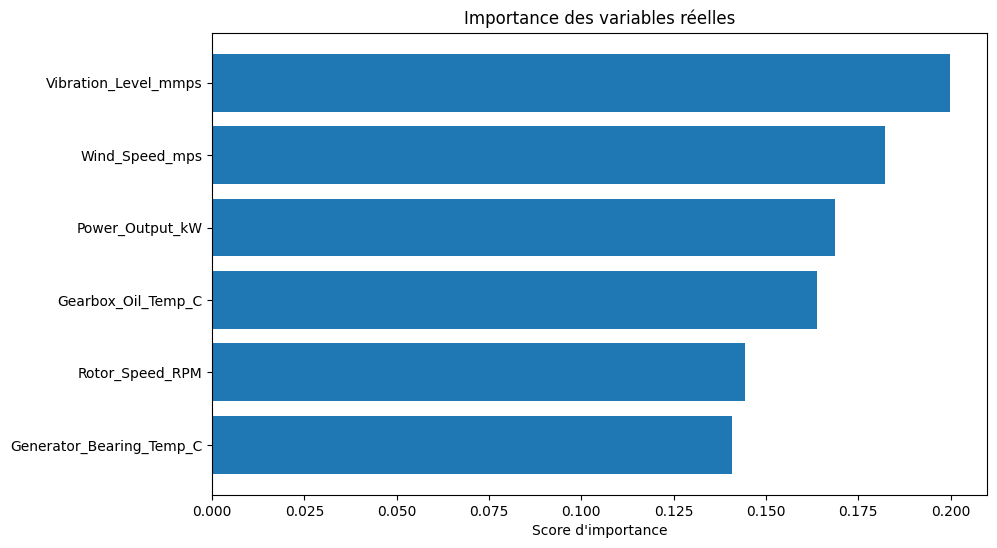

                    Feature  Importance
5      Vibration_Level_mmps    0.199887
1            Wind_Speed_mps    0.182335
2           Power_Output_kW    0.168813
3        Gearbox_Oil_Temp_C    0.163753
0           Rotor_Speed_RPM    0.144375
4  Generator_Bearing_Temp_C    0.140837


In [51]:
# 1. RÉCUPÉRATION DES NOMS (L'erreur était ici)
# On ne veut pas les données de X, on veut ses TITRES de colonnes
feature_names = X.columns 

# 2. Extraction des scores d'importance du modèle
importances = rf.feature_importances_

# 3. Création du DataFrame avec les VRAIS noms
# Maintenant, 'Feature' recevra une liste de 4 noms, et 'Importance' 4 scores.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Affichage
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Importance des variables réelles")
plt.xlabel("Score d'importance")
plt.show()

print(feature_importance_df)

---
## 5. Évaluation finale du modèle

### Matrice de confusion

On prédit sur le jeu de test et on visualise la matrice de confusion pour analyser les erreurs par classe.

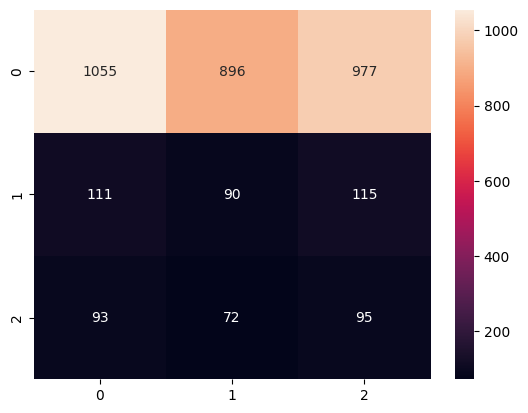

In [52]:
Y_train_pred = rf.predict(X_train)
Y_test_pred = rf.predict(X_test)

cm = confusion_matrix(Y_test, Y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

### Scores de performance

Récapitulatif des métriques finales sur le jeu de test (accuracy, F1 macro, rapport de classification complet).

In [53]:
# Métriques finales
print("Accuracy (train) :", accuracy_score(Y_train, Y_train_pred))
print("Accuracy (test)  :", accuracy_score(Y_test, Y_test_pred))
print()
print("F1-Score macro (train) :", f1_score(Y_train, Y_train_pred, average='macro'))
print("F1-Score macro (test)  :", f1_score(Y_test, Y_test_pred, average='macro'))
print()
print("Rapport de classification complet :")
print(classification_report(Y_test, Y_test_pred, target_names=['Pas de maintenance', 'Maintenance mineure', 'Maintenance majeure']))

Accuracy (train) : 0.4330764840182648
Accuracy (test)  : 0.3538812785388128

F1-Score macro (train) : 0.35615055939720247
F1-Score macro (test)  : 0.2554170955052694

Rapport de classification complet :
                     precision    recall  f1-score   support

 Pas de maintenance       0.84      0.36      0.50      2928
Maintenance mineure       0.09      0.28      0.13       316
Maintenance majeure       0.08      0.37      0.13       260

           accuracy                           0.35      3504
          macro avg       0.33      0.34      0.26      3504
       weighted avg       0.71      0.35      0.44      3504



---
## Conclusion

Ce notebook a couvert l'ensemble du pipeline de Machine Learning pour la maintenance prédictive des éoliennes :

- **EDA** : le dataset est globalement propre, avec quelques valeurs manquantes et un fort déséquilibre de classes (label 0 majoritaire).
- **Nettoyage** : suppression de 3 colonnes peu informatives (`Turbine_ID`, `Ambient_Temp_C`, `Humidity_pct`). Le dataset nettoyé est sauvegardé dans `data/processed/`.
- **Modèles testés** : Baseline naïve → Régression Logistique → Lasso → **Random Forest** (vainqueur).
- **Random Forest optimisé** : meilleur compromis biais/variance, F1-Score macro test autour de **0.58–0.62** selon les hyperparamètres.

**Points d'amélioration possibles :**
- Feature engineering temporel (lags, moyennes glissantes) pour exploiter la nature séquentielle des données
- Gestion du déséquilibre de classes via SMOTE ou oversampling
- Entraînement conjoint Turbine 1 + Turbine 2 avec validation croisée

Le modèle final est sauvegardé via `src/train_model.py` dans le dossier `models/`.